# Sensitivity Analysis — NYP Screening Digital Twin

**What this notebook does:**
1. Runs the full 80-year baseline simulation, plus one run for each of 5 grid values × 15 parameters = **76 total simulations** (parallelized across CPU cores).
2. For each (param, output) pair, computes an **elasticity** ε = ΔY% / ΔX% — the % change in the output per % change in the parameter.
3. Renders per-section heatmaps + a top-15 ranked table.

**How to read an elasticity:**
- ε ≈ **0** → output is insensitive to the parameter.
- ε ≈ **+1** → 1% increase in the parameter causes a 1% increase in the output (linear pass-through).
- ε ≈ **−1** → inversely linear.
- ε > 1 in magnitude → output amplifies the input (high leverage).

**Important — this is NOT scenario analysis.** Each simulation perturbs exactly one parameter for the duration of that single run only (in-memory, auto-reverted). No files on disk change. No scenarios.

Outputs land in `notebooks/Sensitivity Visualizations/`.

---

In [1]:
import sys, os
sys.path.insert(0, '../src')
sys.path.insert(0, '../ModelParameters')

from sensitivity import (
    SENSITIVITY_PARAMS, run_sweep,
    compute_elasticities, top_sensitive_pairs, render_all,
)

VIZ_DIR = '../notebooks/Sensitivity Visualizations'
os.makedirs(VIZ_DIR, exist_ok=True)

print(f'Parameters to sweep: {len(SENSITIVITY_PARAMS)}')
for p in SENSITIVITY_PARAMS:
    print(f'  {p.name:<40}  grid={p.grid}  ({p.section})')
print(f'\nTotal runs this sweep: 1 baseline + {len(SENSITIVITY_PARAMS)} × 5 = {1 + 5*len(SENSITIVITY_PARAMS)}')

Parameters to sweep: 15
  DAILY_PATIENTS                            grid=[1, 2, 2, 3, 4]  (operational)
  CAPACITIES.cytology                       grid=[2, 3, 4, 6, 8]  (operational)
  CAPACITIES.colposcopy                     grid=[2, 3, 4, 6, 8]  (operational)
  CAPACITIES.ldct                           grid=[2, 3, 4, 6, 8]  (operational)
  CAPACITIES.lung_biopsy                    grid=[2, 3, 4, 6, 8]  (operational)
  CAPACITIES.leep                           grid=[2, 3, 4, 6, 8]  (operational)
  FOLLOWUP_DELAY_DAYS.colposcopy            grid=[20, 35, 50, 75, 100]  (operational)
  TURNAROUND_DAYS.ldct_notification         grid=[3, 7, 10, 15, 21]  (operational)
  LTFU_PROBS.queue_primary_daily            grid=[0.03, 0.07, 0.1, 0.15, 0.2]  (clinical)
  LTFU_PROBS.queue_secondary_daily          grid=[0.03, 0.07, 0.1, 0.15, 0.2]  (clinical)
  HPV_POSITIVE_COLPOSCOPY_PROB              grid=[0.4, 0.5, 0.6, 0.7, 0.8]  (clinical)
  SMOKER_RATE                               grid=[0.08, 0.1,

## 1. Run the sweep

Full 80-year sim × 76 runs, parallelized. On ~8 cores this takes ~40 minutes; on 16 cores ~20 minutes. Progress prints below as each run finishes.

In [2]:
csv_path = run_sweep(seed=42)
print(f'\nResults CSV: {csv_path}')

[sweep] 76 runs × full 80 yr each, 11 parallel workers
[sweep] writing → /Users/alexandrapaiz/Desktop/NYP/notebooks/Sensitivity Visualizations/sweep_seed42.csv
  [  1/76] DAILY_PATIENTS                           grid=1        32s  ETA 41.5min
  [  2/76] DAILY_PATIENTS                           grid=2        61s  ETA 38.2min
  [  3/76] CAPACITIES.cytology                      grid=8        61s  ETA 25.1min
  [  4/76] CAPACITIES.cytology                      grid=3        62s  ETA 18.9min
  [  5/76] DAILY_PATIENTS                           grid=2        62s  ETA 15.0min
  [  6/76] CAPACITIES.cytology                      grid=4        62s  ETA 12.3min
  [  7/76] CAPACITIES.cytology                      grid=2        63s  ETA 10.4min
  [  8/76] CAPACITIES.cytology                      grid=6        62s  ETA 9.0min
  [  9/76] __baseline__                             grid=None     63s  ETA 7.9min
  [ 10/76] DAILY_PATIENTS                           grid=3        84s  ETA 9.3min
  [ 11/76] DA

## 2. Compute elasticities

In [3]:
elas = compute_elasticities(csv_path)
print(f'Elasticity matrix: {elas.shape[0]} parameters × {elas.shape[1]} outputs')
print(f'Non-null cells: {elas.notna().sum().sum():,}')
elas.head()

Elasticity matrix: 15 parameters × 113 outputs
Non-null cells: 1,410


,cervical.annual_cytology_mean,cervical.annual_hpv_alone_mean,cervical.annual_total_mean,cervical.cytology.ASC-H_rate_pct,cervical.cytology.ASCUS_rate_pct,cervical.cytology.HSIL_rate_pct,cervical.cytology.LSIL_rate_pct,cervical.cytology.NORMAL_rate_pct,cervical.cytology.abnormal_rate_pct,cervical.hpv_alone.positive_rate_pct,...,treatment.cervical_completion_rate_pct,treatment.cervical_excisional_total,treatment.cin23_diagnosed,treatment.cone_biopsy_total,treatment.leep_annual_mean,treatment.leep_total,treatment.lung_annual_mean,treatment.lung_completion_rate_pct,treatment.lung_total,treatment.surveillance_total
CAPACITIES.colposcopy,4.527649e-04,-1.010072e-02,-4.854791e-03,-3.985988e-02,-3.732352e-02,-5.260908e-02,-0.001009,2.018788e-03,-0.016345,2.721879e-02,...,2.103465e-03,-1.401476e-02,-1.611823e-02,NaN,-1.401476e-02,-1.401476e-02,0.063035,-1.064255e-15,0.063035,-1.198724e-02
CAPACITIES.cytology,2.090055e-01,-6.950794e-02,-1.794937e-02,2.916871e-02,-3.624378e-02,3.812669e-02,-0.014952,4.042585e-03,-0.032833,5.466376e-05,...,9.058910e-03,1.279837e-01,1.189248e-01,NaN,1.279837e-01,1.279837e-01,0.016394,2.660637e-16,0.016394,1.210535e-01
CAPACITIES.ldct,5.228821e-03,-1.735270e-02,-4.898430e-03,3.828576e-02,-1.631578e-02,-3.687197e-02,0.045105,-1.482826e-03,0.011964,1.274353e-02,...,-3.591030e-03,4.350857e-03,7.941887e-03,NaN,4.350857e-03,4.350857e-03,0.081792,-5.321274e-16,0.081792,-1.479009e-02
CAPACITIES.leep,5.221973e-03,1.656312e-02,5.574290e-03,-1.017725e-02,-6.729273e-03,-2.745371e-02,-0.016234,1.081322e-03,-0.008802,-9.134375e-03,...,1.113984e-02,2.150562e-03,-8.989282e-03,NaN,2.150562e-03,2.150562e-03,0.055787,2.660637e-16,0.055787,-1.144965e-02
CAPACITIES.lung_biopsy,-1.064255e-15,-5.321274e-16,-1.064255e-15,-4.988695e-17,-1.330319e-16,-1.039311e-18,0.000000,-2.660637e-16,0.000000,1.330319e-16,...,2.660637e-16,-7.981911e-16,-1.596382e-15,NaN,2.660637e-16,-7.981911e-16,0.000000,2.660637e-16,0.000000,-1.596382e-15


## 3. Top 15 most-sensitive (parameter, output) pairs

Ranked by absolute elasticity. These are the knobs with the biggest leverage on any single output.

In [4]:
top = top_sensitive_pairs(elas, n=15)
top

,param,output,elasticity,magnitude
0,CAPACITIES.ldct,queue.overflow.ldct_total,-5.794833,5.794833
1,DAILY_PATIENTS,queue.primary.overcap_pct,4.239369,4.239369
2,CAPACITIES.cytology,queue.overflow.cytology_total,-3.758470,3.758470
3,CAPACITIES.ldct,queue.primary.overcap_pct,-3.593315,3.593315
4,CAPACITIES.cytology,queue.secondary.overflow_mean,-3.491827,3.491827
5,CAPACITIES.cytology,queue.primary.overcap_pct,-2.934728,2.934728
6,DAILY_PATIENTS,queue.overflow.ldct_total,2.592496,2.592496
7,DAILY_PATIENTS,queue.overflow.cytology_total,2.179486,2.179486
8,DAILY_PATIENTS,queue.primary.overflow_mean,1.923891,1.923891
9,DAILY_PATIENTS,finance.unserved_total_usd,-1.587433,1.587433


## 4. Render heatmaps

One heatmap per section of the stats table (population, queues, cervical, lung, colposcopy, lung_bx, ltfu, treatment, mortality, finance), plus a top-pairs summary. All saved to `notebooks/Sensitivity Visualizations/`.

In [5]:
saved = render_all(elas, VIZ_DIR, top_n=15)
print(f'Saved {len(saved)} files:')
for p in saved:
    print(f'  {p}')

Saved 11 files:
  ../notebooks/Sensitivity Visualizations/sensitivity_cervical.png
  ../notebooks/Sensitivity Visualizations/sensitivity_colposcopy.png
  ../notebooks/Sensitivity Visualizations/sensitivity_finance.png
  ../notebooks/Sensitivity Visualizations/sensitivity_ltfu.png
  ../notebooks/Sensitivity Visualizations/sensitivity_lung.png
  ../notebooks/Sensitivity Visualizations/sensitivity_lung_bx.png
  ../notebooks/Sensitivity Visualizations/sensitivity_mortality.png
  ../notebooks/Sensitivity Visualizations/sensitivity_pop.png
  ../notebooks/Sensitivity Visualizations/sensitivity_queue.png
  ../notebooks/Sensitivity Visualizations/sensitivity_treatment.png
  ../notebooks/Sensitivity Visualizations/sensitivity_top_pairs.png


## 5. Preview each heatmap inline

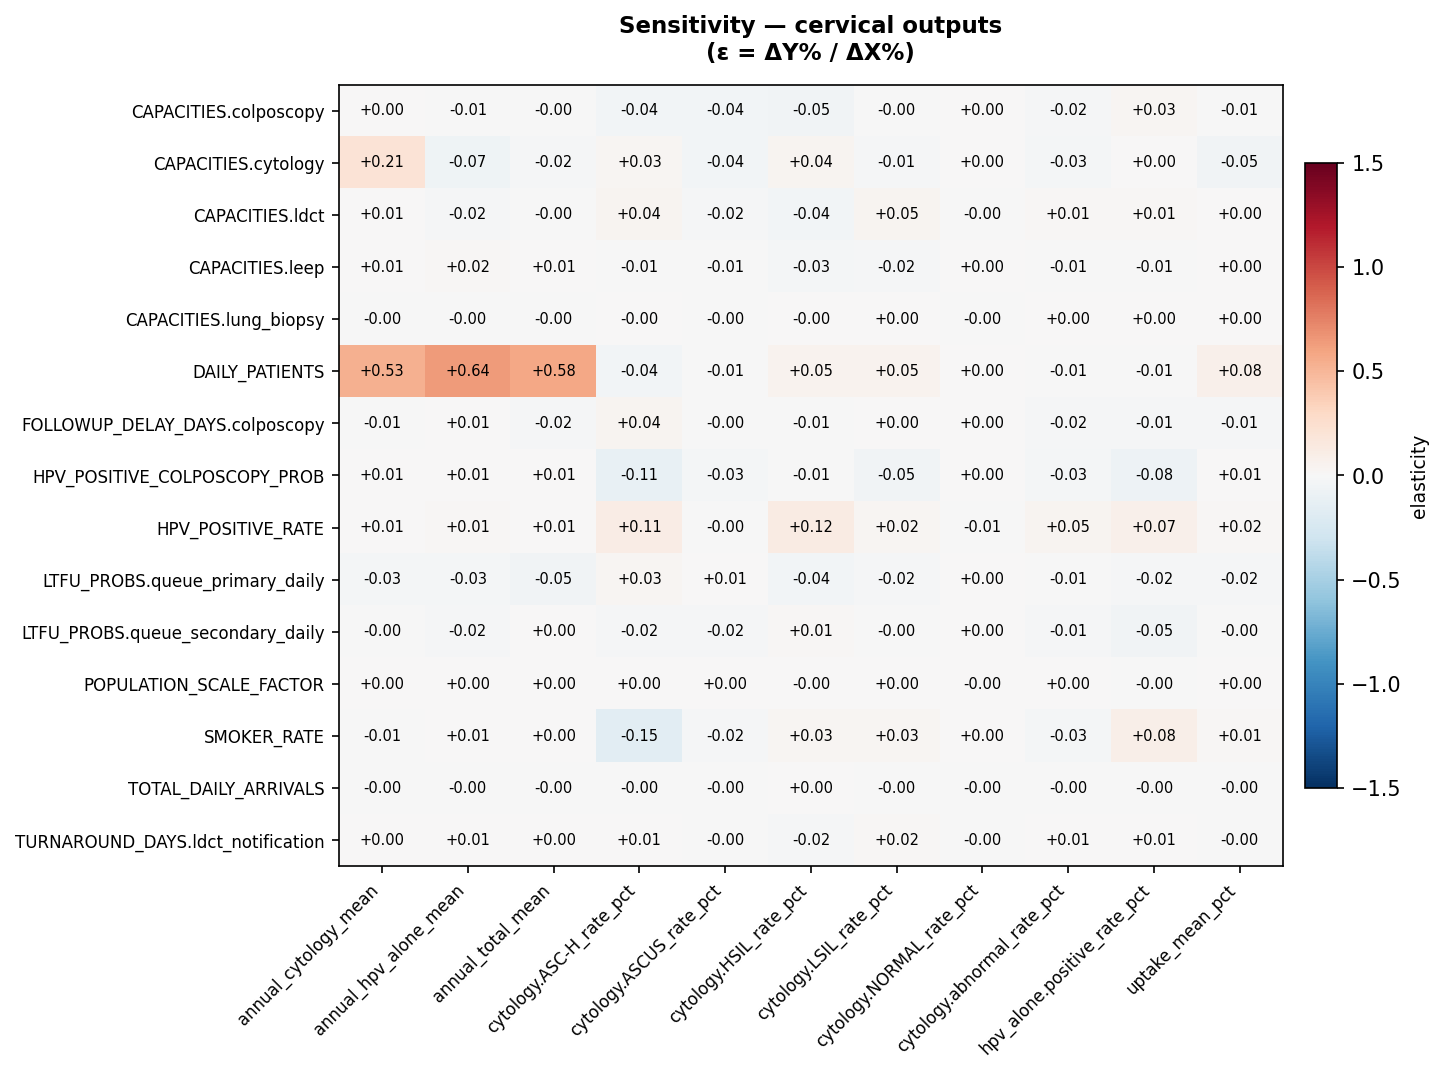

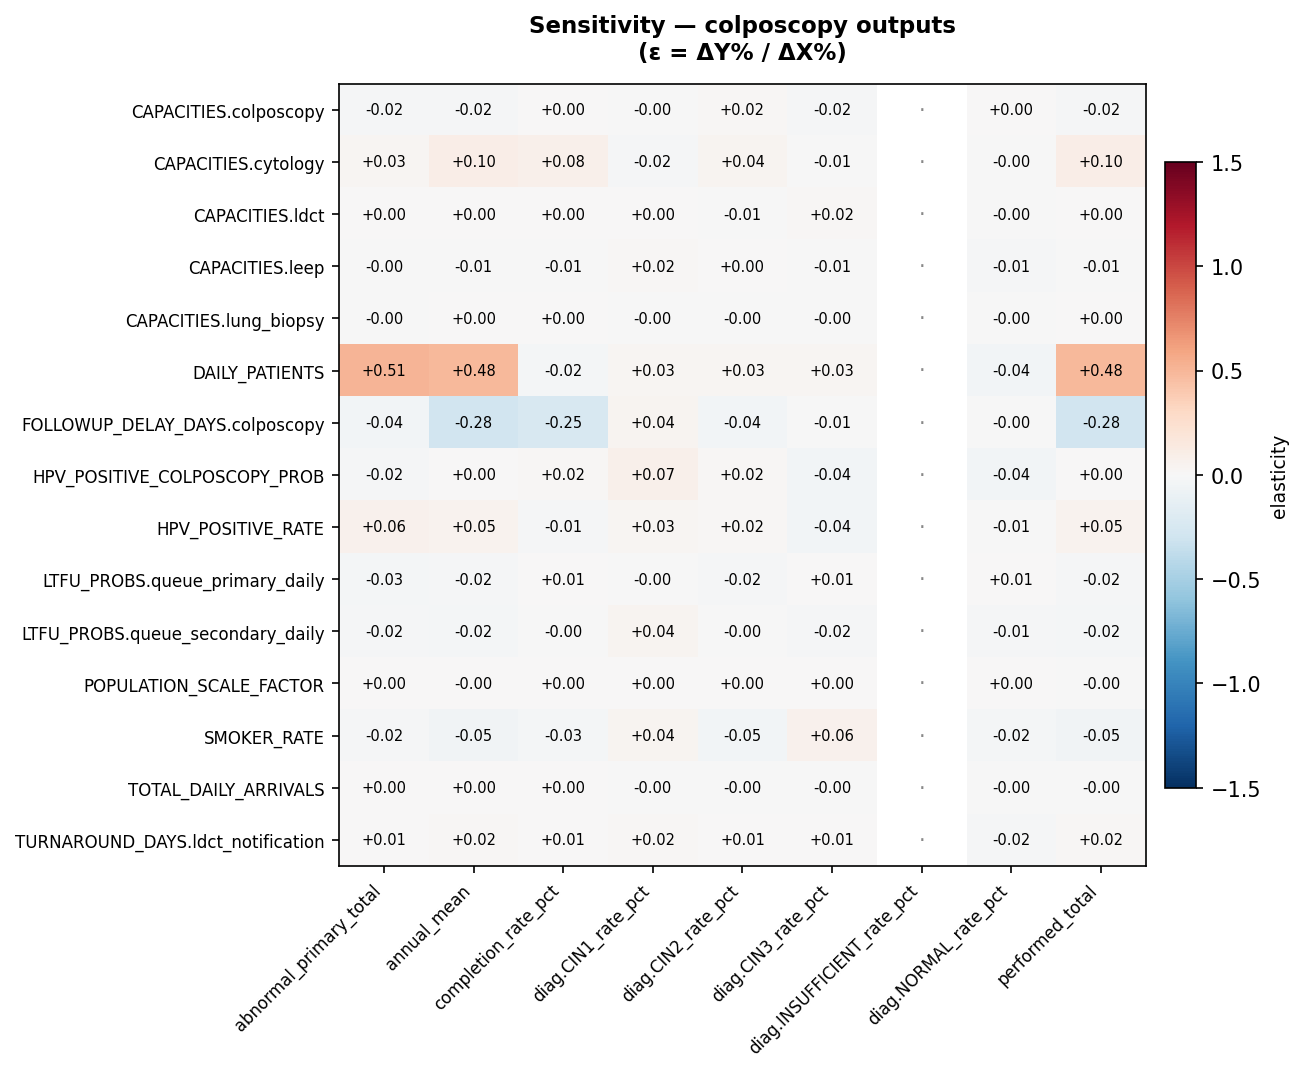

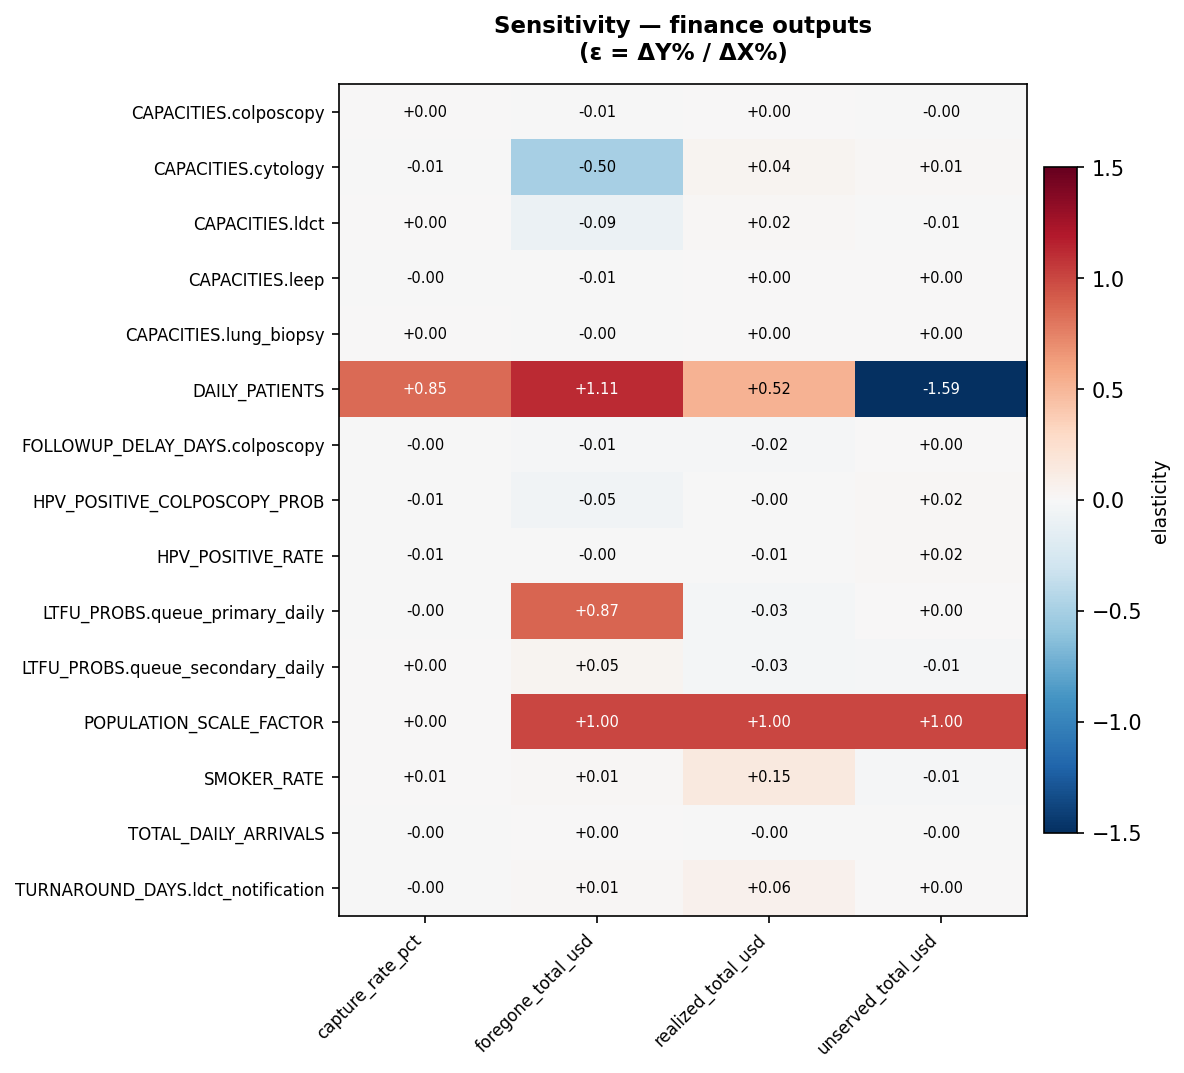

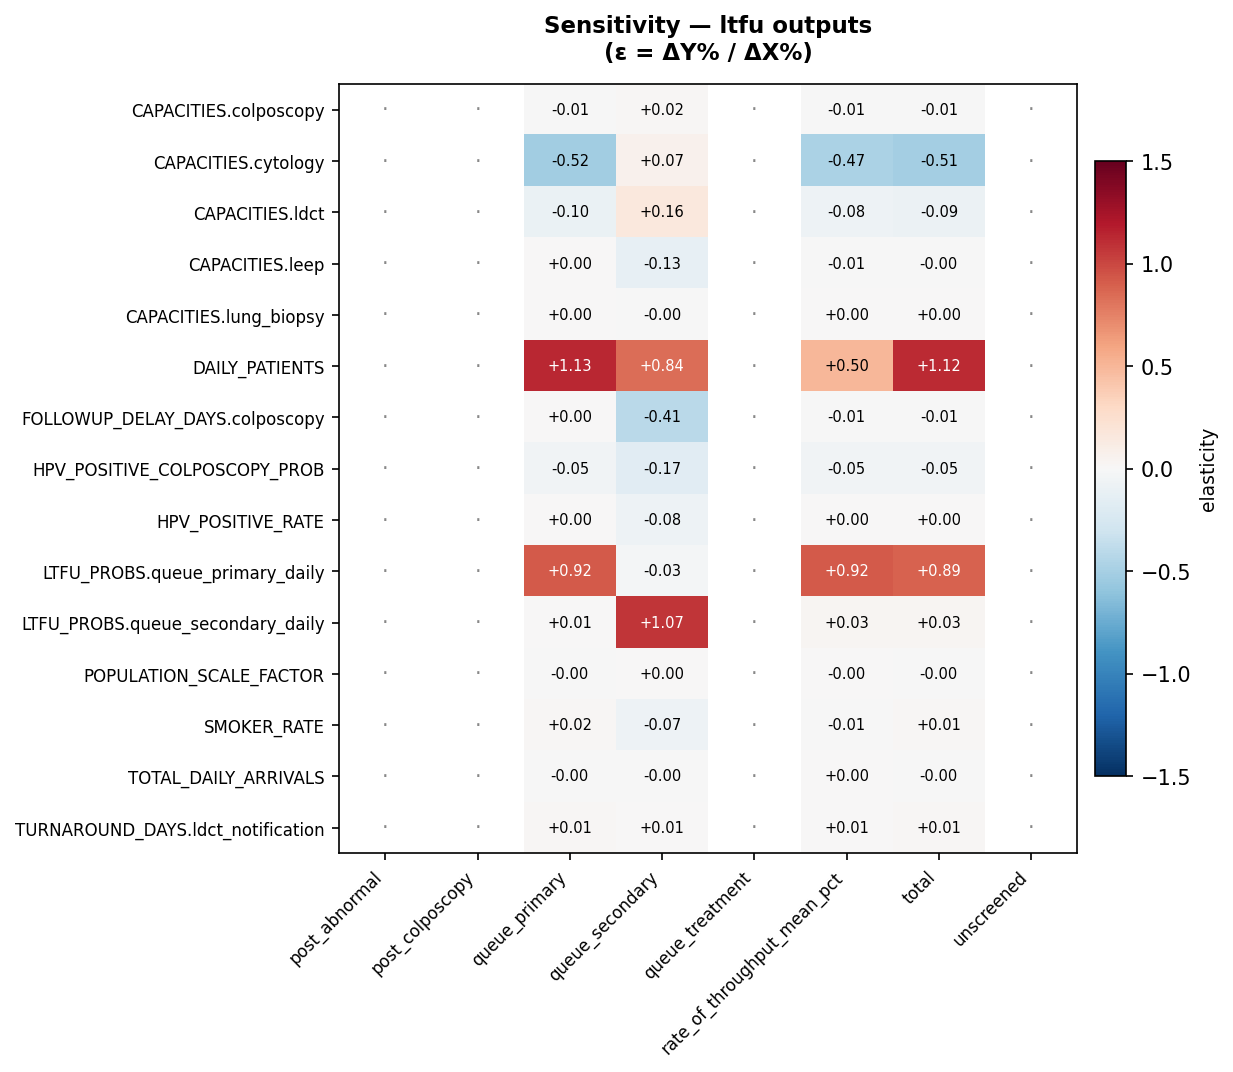

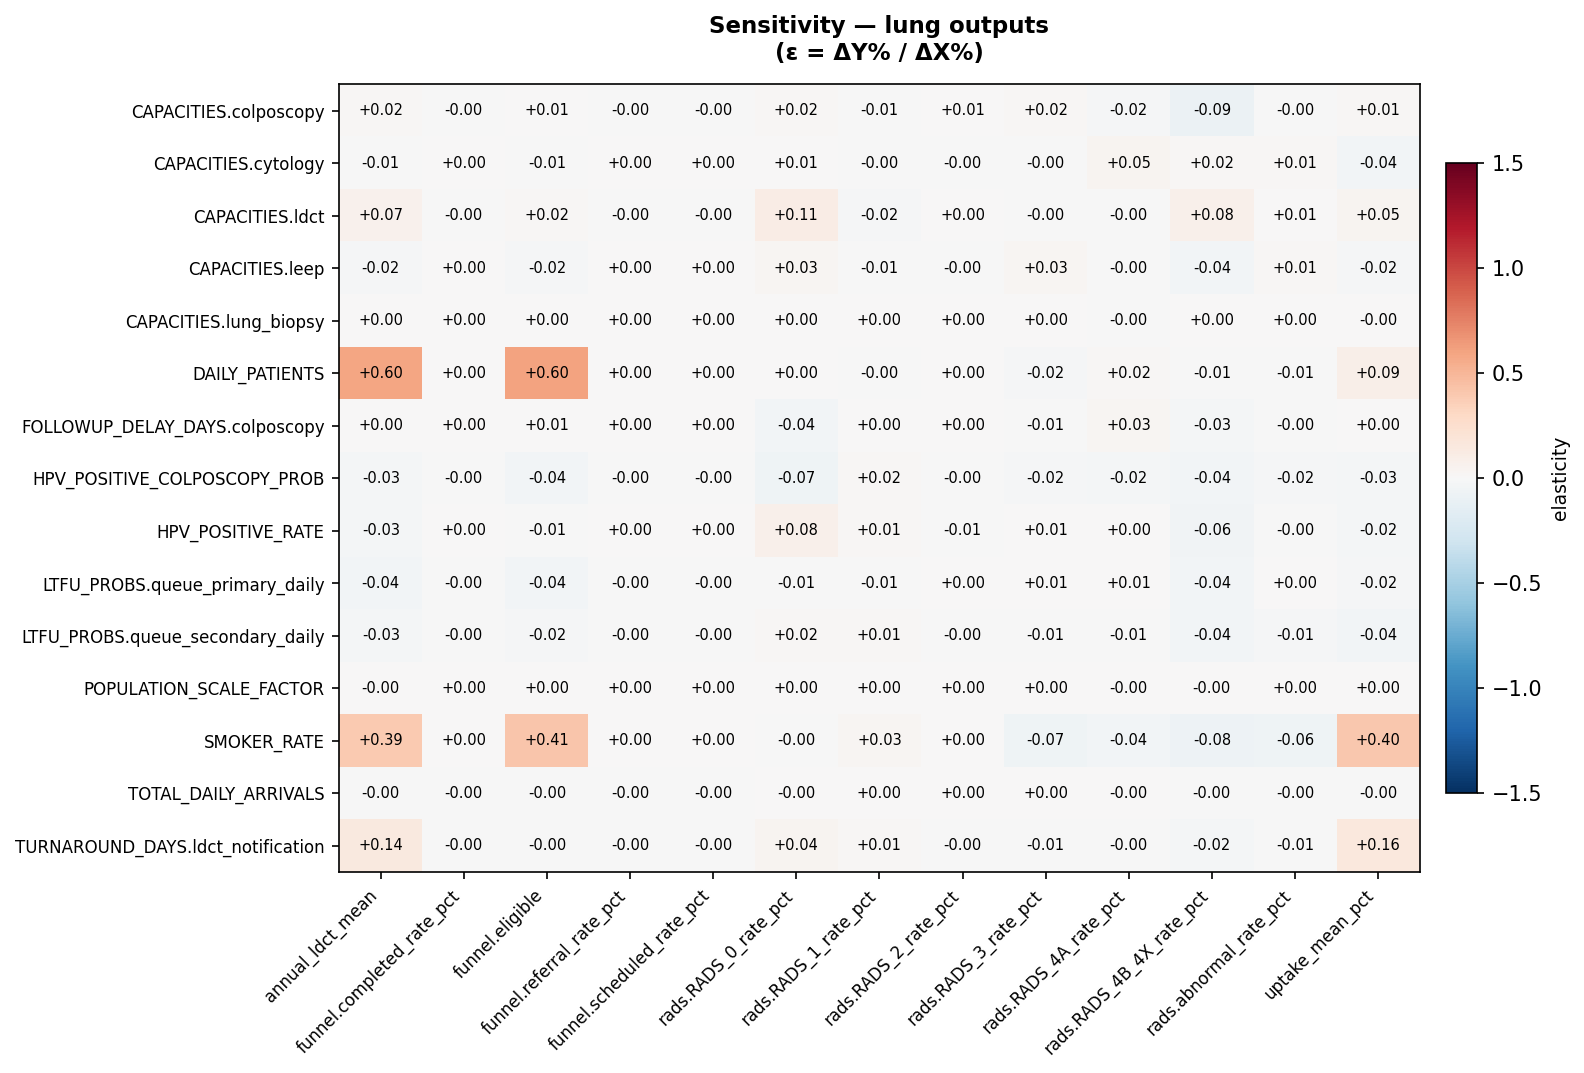

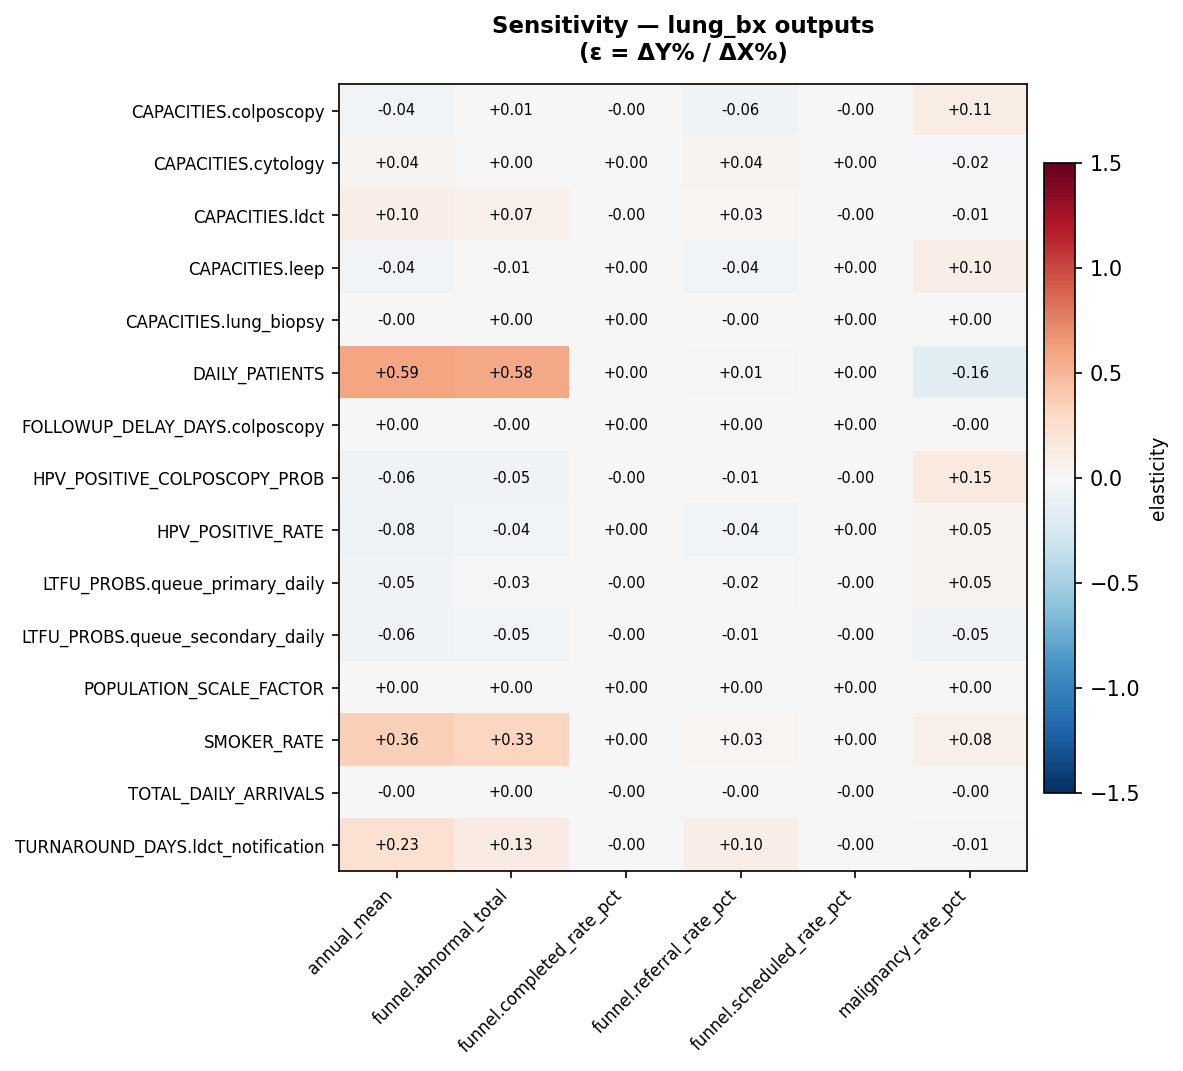

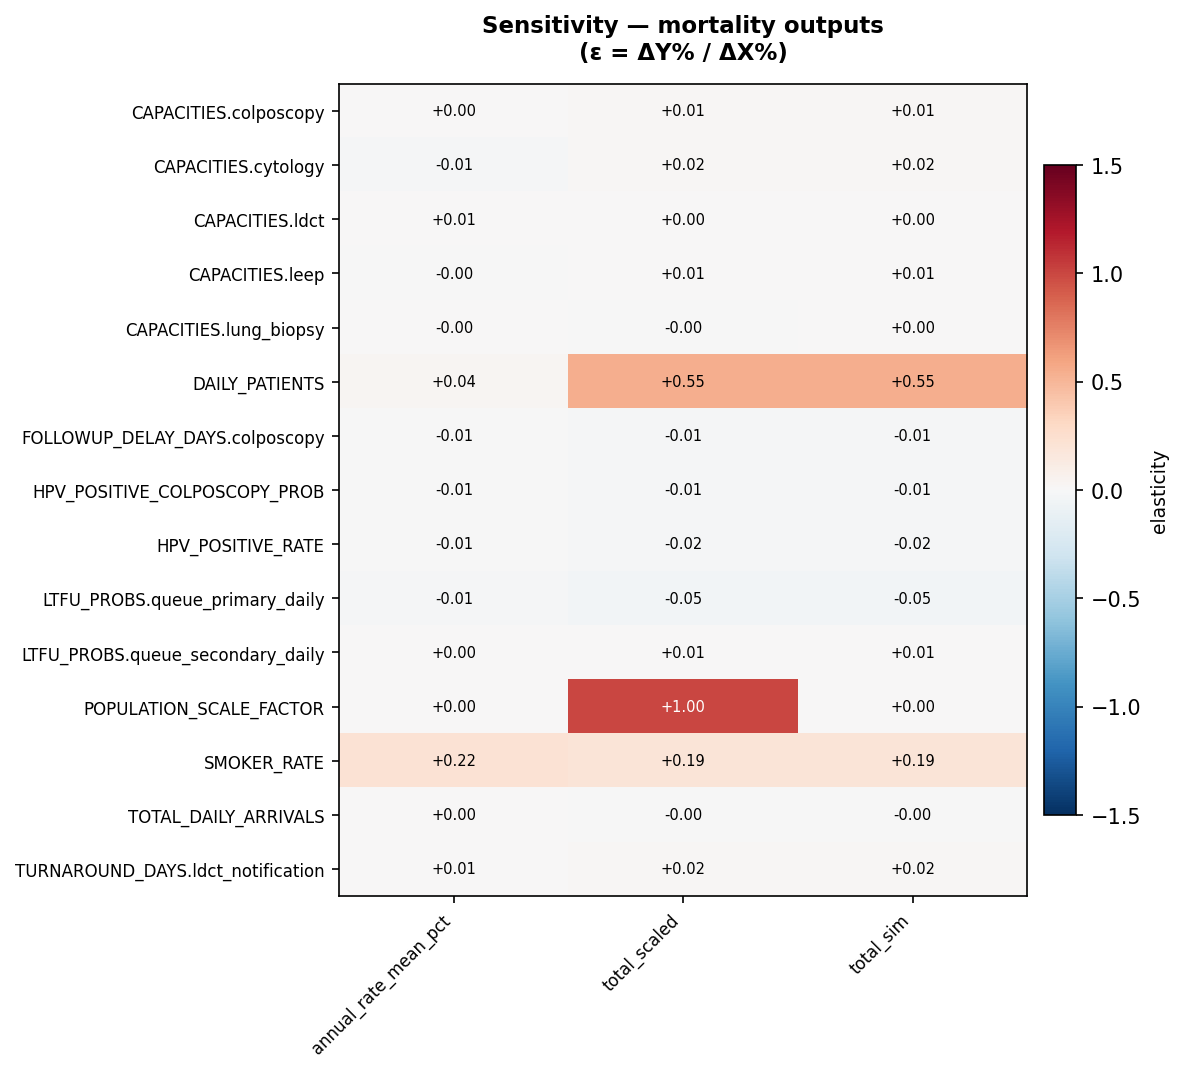

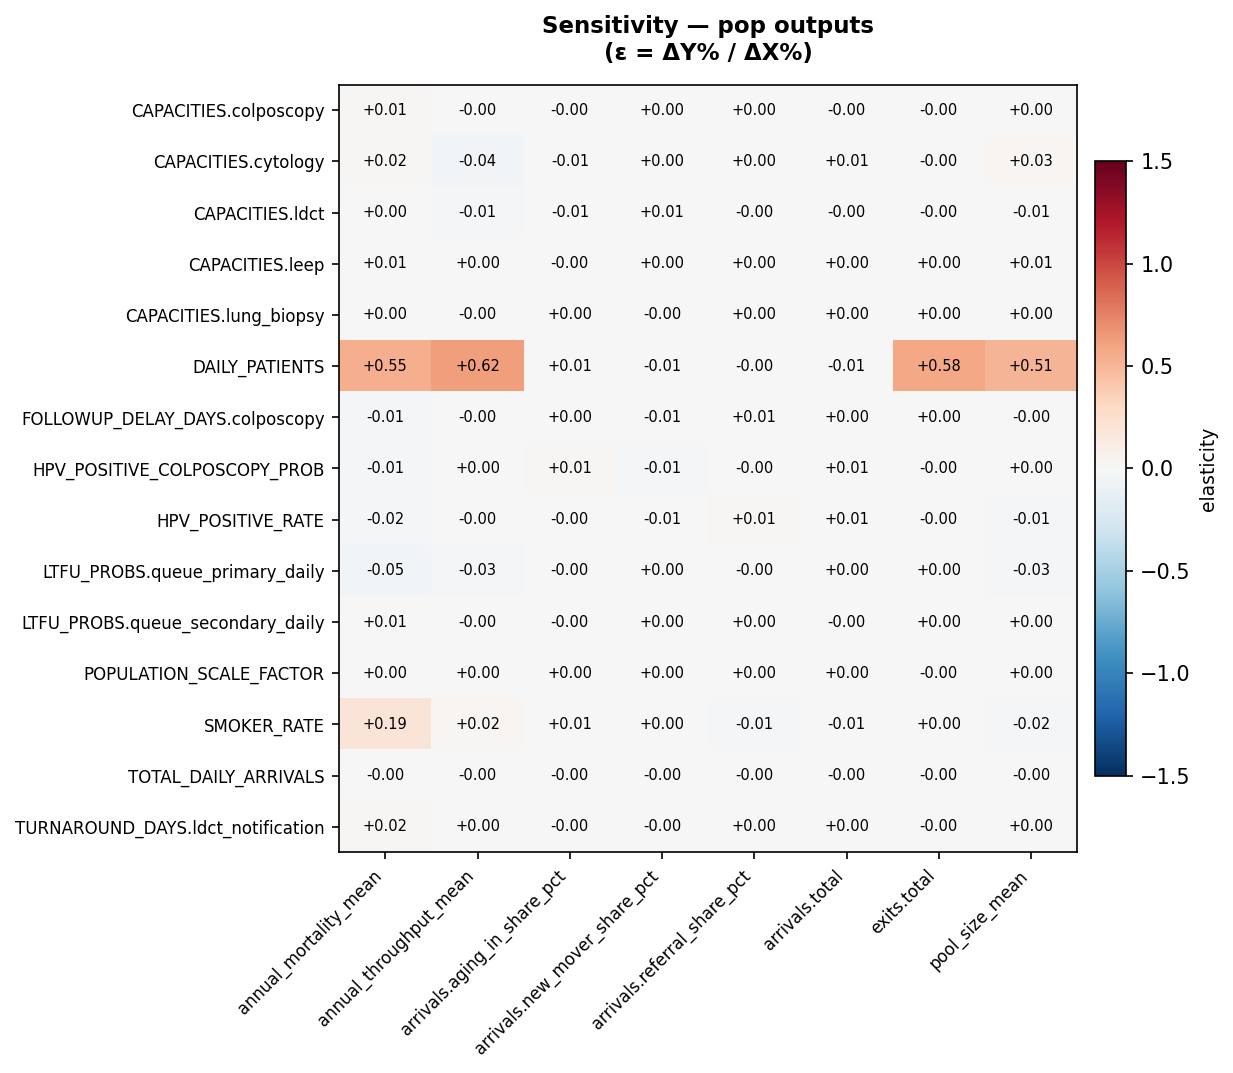

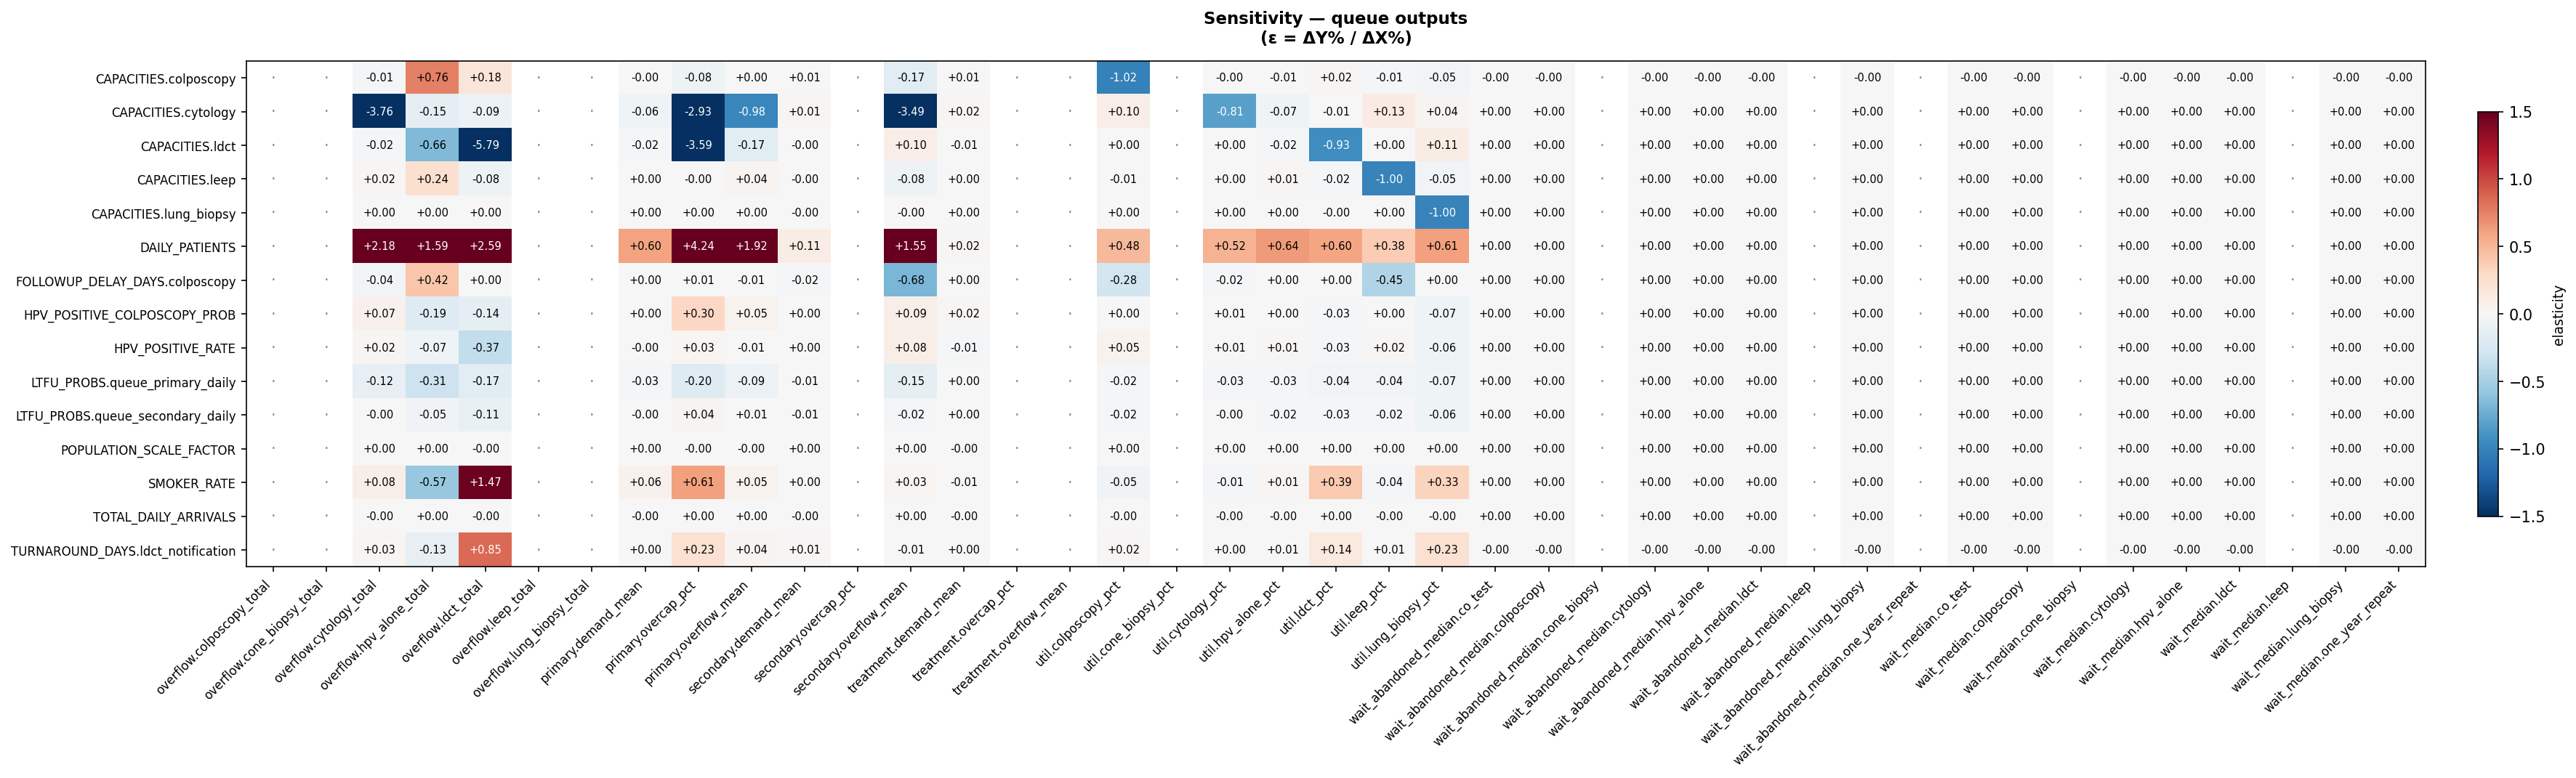

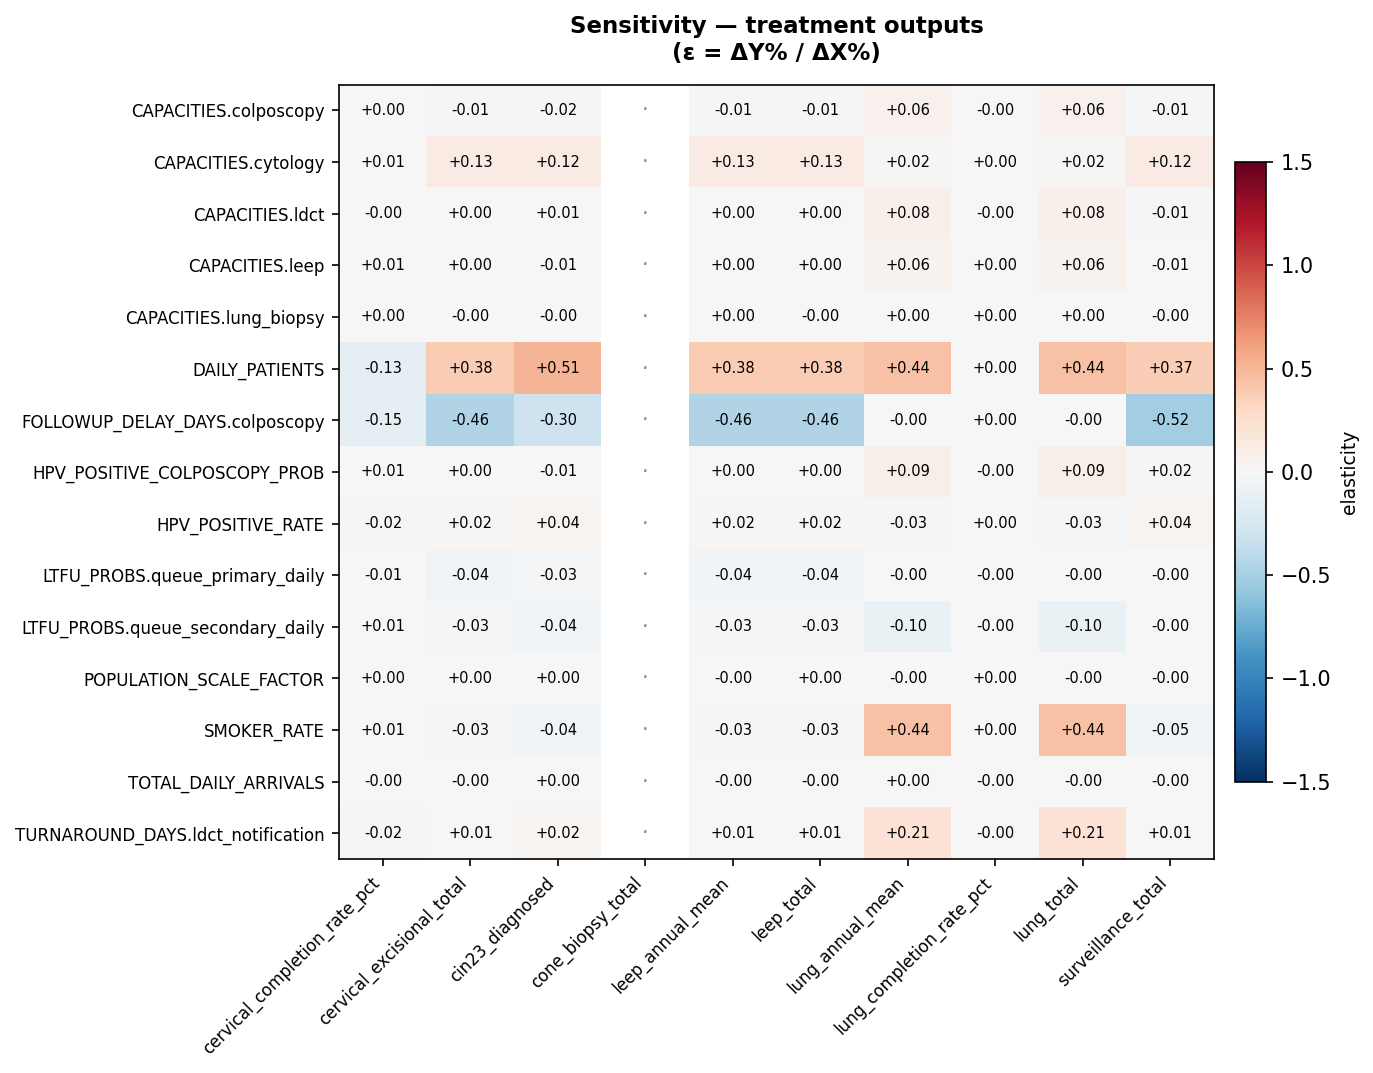

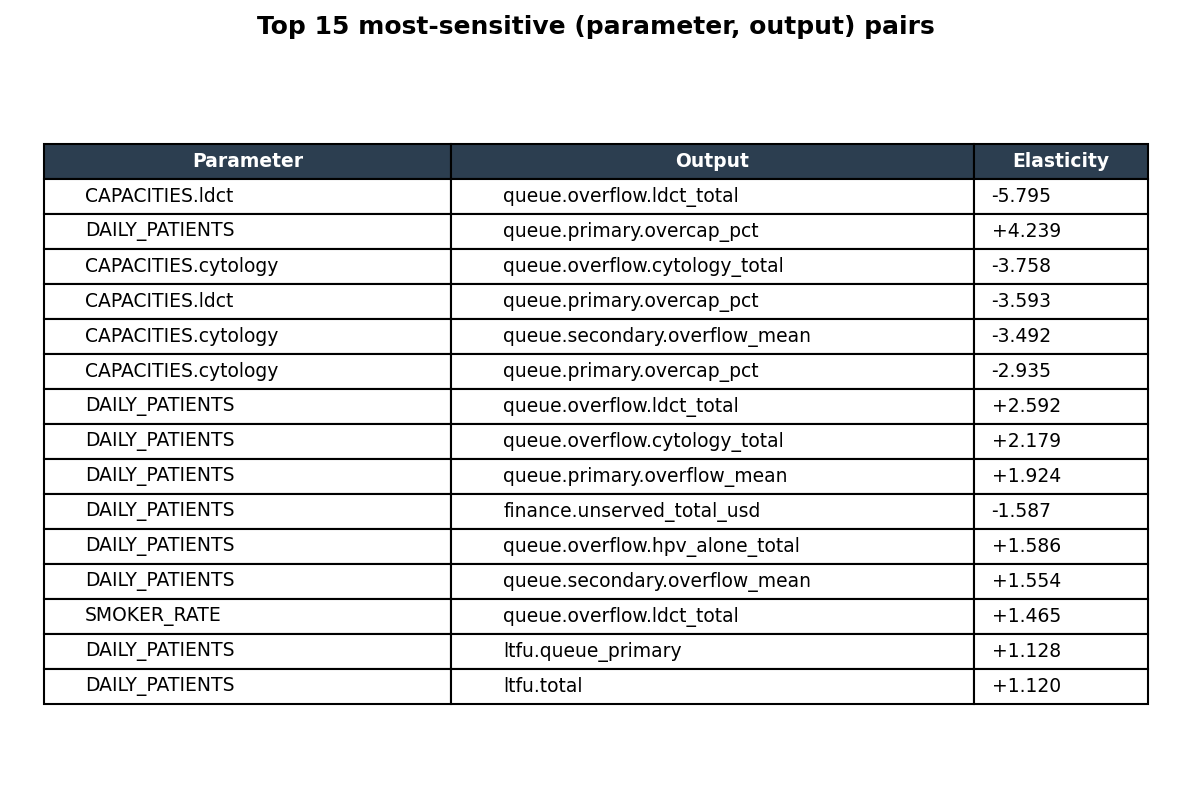

In [6]:
from IPython.display import Image, display
for p in saved:
    display(Image(p))

---

**Linearity sanity check:** `POPULATION_SCALE_FACTOR` should produce elasticities ≈ 1.0 on every dollar output (`finance.*_usd`). If that column is close to 1.0, the scale factor is being applied correctly. Any other value would indicate a bug in `compute_revenue()` or `compute_output_metrics()`.

**Next:** look at the per-section heatmaps; anything with |ε| > 0.5 is a meaningfully leveraged relationship worth investigating.